# <b>Introduction to XGBoost Classifier<b>

## Load the dataset / Analysis on it 

In [ ]:
# Import the required Libraries 
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split , cross_val_score
from xgboost import XGBClassifier,plot_importance,plot_tree
from sklearn.metrics import classification_report,confusion_matrix

In [ ]:
# For this Introduction we will be using the popular churning dataset of the customers, where we try to predict 
# the number of customers stopping to use a service . Our goal is to minimize the churn rate by creating such a model
# that it is able to predict the churn before hand . We can device strategies to make sure those customers
# dont leave the service.

In [ ]:
df = pd.read_csv('datasets\churn.csv') # Load the dataset

In [ ]:
df.head() # Examine head

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info() # Found out that there are many object columns ;  need to convert them to numeric type.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe() # Describes the numeric only columns 

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
# In this step I created a for loop which iterates the columns and checks whether the column is object :
#   If object then checks the length : If the length is short (<11) then we print the columns , if not then we append it to a temporary list.

'''
Why do this step ? 
            To get a clear idea of the unique values : numerical , string , datetime , formatted_string , null values and any anamolies.
            It is also to know which values are common in columns and also will be used in mapping further .
'''

temp = []
for x in df.columns:
    if df[x].dtype == object :
        if len(df[x].unique()) <11 :
            print(
                    f'{x} :  \n {df[x].unique()} \n '
            )
        else:
            temp.append(x)
print(f'Other columns that are object but many unique values : {temp}')

gender :  
 ['Female' 'Male'] 
 
Partner :  
 ['Yes' 'No'] 
 
Dependents :  
 ['No' 'Yes'] 
 
PhoneService :  
 ['No' 'Yes'] 
 
MultipleLines :  
 ['No phone service' 'No' 'Yes'] 
 
InternetService :  
 ['DSL' 'Fiber optic' 'No'] 
 
OnlineSecurity :  
 ['No' 'Yes' 'No internet service'] 
 
OnlineBackup :  
 ['Yes' 'No' 'No internet service'] 
 
DeviceProtection :  
 ['No' 'Yes' 'No internet service'] 
 
TechSupport :  
 ['No' 'Yes' 'No internet service'] 
 
StreamingTV :  
 ['No' 'Yes' 'No internet service'] 
 
StreamingMovies :  
 ['No' 'Yes' 'No internet service'] 
 
Contract :  
 ['Month-to-month' 'One year' 'Two year'] 
 
PaperlessBilling :  
 ['Yes' 'No'] 
 
PaymentMethod :  
 ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)'] 
 
Churn :  
 ['No' 'Yes'] 
 
Other columns that are object but many unique values : ['customerID', 'TotalCharges']


## Data Preprocessing

In [ ]:
'''
    Analyzing the above output in text editor , I found out that many of the columns had the O/P:
     ['No' 'Yes'] , ['No' 'Yes' 'No internet service'] .

     So we can use this info when mapping values where we will select these groups (columns with same output) ad map them seperately,
     reducing load.

     For the other columns left we will decide a different strategy
'''
# Columns with unique values : ['No' 'Yes']
columns_to_map_yes_no = ['Partner','Dependents','PhoneService','PaperlessBilling','Churn']
# Their Map
map_yes_no = {
                    'No'  : 0,
                    'Yes' : 1
}

# Columns with unique values : ['No' 'Yes','No internet service]
columns_to_map_yes_no_internet_service = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
# Their map
map_yes_no_internet_service = { 
                    'No internet service' : -1,
                    'No'  : 0,
                    'Yes' : 1
}

In [ ]:
# Mapping with the replace method , we could have also used the map() function.

In [215]:
df[columns_to_map_yes_no] = df[columns_to_map_yes_no].replace(map_yes_no).infer_objects(copy=False)

C:\Users\hp\AppData\Local\Temp\ipykernel_792\2741579614.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[columns_to_map_yes_no] = df[columns_to_map_yes_no].replace(map_yes_no).infer_objects(copy=False)


In [ ]:
df[columns_to_map_yes_no_internet_service] = df[columns_to_map_yes_no_internet_service].replace(map_yes_no_internet_service).infer_objects(copy=False)

C:\Users\hp\AppData\Local\Temp\ipykernel_792\3019143004.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[columns_to_map_yes_no_internet_service] = df[columns_to_map_yes_no_internet_service].replace(map_yes_no_internet_service)


In [ ]:
df.info() # Check for changes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   int64  
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   int64  
 10  OnlineBackup      7043 non-null   int64  
 11  DeviceProtection  7043 non-null   int64  
 12  TechSupport       7043 non-null   int64  
 13  StreamingTV       7043 non-null   int64  
 14  StreamingMovies   7043 non-null   int64  
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   int64  


In [ ]:
# A loop for checking the remaining objects left and their values
[
    f'{x} : {df[x].unique()} ' for x in df.columns if (df[x].dtypes == object) and len(df[x].unique()) < 11 
]

["gender : ['Female' 'Male'] ",
 "MultipleLines : ['No phone service' 'No' 'Yes'] ",
 "InternetService : ['DSL' 'Fiber optic' 'No'] ",
 "Contract : ['Month-to-month' 'One year' 'Two year'] ",
 "PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'\n 'Credit card (automatic)'] "]

In [ ]:
# Here After Analyzing I found that I can map the gender column easily into zero and ones.
# The Multiplelines can be mapped using a similar fashion as Columns with unique values : ['No' 'Yes','No internet service] .
# And as for Intenet Service we will map rest with no marked as -1.
# The contract columns in ordinal so we have to map with respect to the order : month,year,yeartwo.
# And as for the Payment column I have used the get_dummies method to OneHotEncode the values /  We could have used the OneHotEncoder.

In [219]:
df['gender'] = df['gender'].map({
                                    'Female' : 0,
                                    'Male' : 1
})

In [220]:
df['MultipleLines'] = df['MultipleLines'].map({
                                                  'No phone service' : -1 , 'No' : 0 ,'Yes'  : 1 
})

In [221]:
df['InternetService'] = df['InternetService'].map({
                                                      'DSL' : 1 ,'Fiber optic' : 0 , 'No' : -1
})

In [222]:
df['Contract'] = df['Contract'].map({
                                        'Month-to-month' : 0 ,  'One year' : 1 , 'Two year' : 2
})

In [224]:
df = pd.get_dummies(df, columns=['PaymentMethod'], prefix='Payment_by_',dtype=int)

In [ ]:
df.columns # Check the new columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'MonthlyCharges', 'TotalCharges', 'Churn',
       'Payment_by__Bank transfer (automatic)',
       'Payment_by__Credit card (automatic)', 'Payment_by__Electronic check',
       'Payment_by__Mailed check'],
      dtype='object')

In [ ]:
df.head() # Check the head

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,Payment_by__Bank transfer (automatic),Payment_by__Credit card (automatic),Payment_by__Electronic check,Payment_by__Mailed check
0,7590-VHVEG,0,0,1,0,1,0,-1,1,0,...,0,0,1,29.85,29.85,0,0,0,1,0
1,5575-GNVDE,1,0,0,0,34,1,0,1,1,...,0,1,0,56.95,1889.5,0,0,0,0,1
2,3668-QPYBK,1,0,0,0,2,1,0,1,1,...,0,0,1,53.85,108.15,1,0,0,0,1
3,7795-CFOCW,1,0,0,0,45,0,-1,1,1,...,0,1,0,42.30,1840.75,0,1,0,0,0
4,9237-HQITU,0,0,0,0,2,1,0,0,0,...,0,0,1,70.70,151.65,1,0,0,1,0


In [ ]:
df['TotalCharges'].replace(" ",np.nan) 
# For the column TotalCharges , it should be in type float but was an object , 
# with each distinct value , also with strings " " marking as empty .
# So we decided to replace them with nan and then we will convert the strings to numeric type
# After conversion the nan values are filled with 0 as it should have been.

0         29.85
1        1889.5
2        108.15
3       1840.75
4        151.65
         ...   
7038     1990.5
7039     7362.9
7040     346.45
7041      306.6
7042     6844.5
Name: TotalCharges, Length: 7043, dtype: object

In [240]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [245]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [ ]:
# We dont need the customerID column as it not necessary for now 
df = df.drop(columns = 'customerID')

In [ ]:
df.info() # Quick check

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   MultipleLines                          7043 non-null   int64  
 7   InternetService                        7043 non-null   int64  
 8   OnlineSecurity                         7043 non-null   int64  
 9   OnlineBackup                           7043 non-null   int64  
 10  DeviceProtection                       7043 non-null   int64  
 11  Tech

In [ ]:
df.describe() # The descripyion of all the columns.

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,Payment_by__Bank transfer (automatic),Payment_by__Credit card (automatic),Payment_by__Electronic check,Payment_by__Mailed check
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,...,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.504756,0.162147,0.483033,0.299588,32.371149,0.903166,0.325004,0.127077,0.069999,0.128212,...,0.171234,0.690473,0.592219,64.761692,2279.734304,0.265370,0.219225,0.216101,0.335794,0.228880
std,0.500013,0.368612,0.499748,0.458110,24.559481,0.295752,0.642730,0.737796,0.706051,0.738369,...,0.758507,0.833755,0.491457,30.090047,2266.794470,0.441561,0.413751,0.411613,0.472301,0.420141
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,0.000000,0.000000,18.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,35.500000,398.550000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,70.350000,1394.550000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,89.850000,3786.600000,1.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,2.000000,1.000000,118.750000,8684.800000,1.000000,1.000000,1.000000,1.000000,1.000000


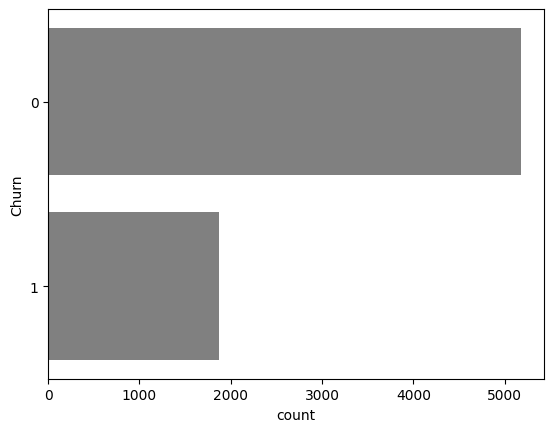

In [ ]:
# I later found out that the Churn column is imbalanced and we need to do something to 
# get better accuracy in model.

# This countplot demonstrates this : 
sns.countplot(
                data = df,
                y = 'Churn',
                color = 'grey'
)
plt.show()

In [ ]:
# The dataset is imbalanced , so therefore we will use scale_pos_weight in XGB
scale_pos_weight_ratio = df['Churn'].value_counts()[0]/df['Churn'].value_counts()[1]

In [ ]:
scale_pos_weight_ratio # The ratio of the columns 

np.float64(2.7683253076511503)

In [ ]:
# Split into features and labels
X , y = df.drop(columns=['Churn']) , df['Churn']

In [ ]:
X # Examine X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Payment_by__Bank transfer (automatic),Payment_by__Credit card (automatic),Payment_by__Electronic check,Payment_by__Mailed check
0,0,0,1,0,1,0,-1,1,0,1,...,0,0,0,1,29.85,29.85,0,0,1,0
1,1,0,0,0,34,1,0,1,1,0,...,0,0,1,0,56.95,1889.50,0,0,0,1
2,1,0,0,0,2,1,0,1,1,1,...,0,0,0,1,53.85,108.15,0,0,0,1
3,1,0,0,0,45,0,-1,1,1,0,...,0,0,1,0,42.30,1840.75,1,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,0,0,0,1,70.70,151.65,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,1,1,0,...,1,1,1,1,84.80,1990.50,0,0,0,1
7039,0,0,1,1,72,1,1,0,0,1,...,1,1,1,1,103.20,7362.90,0,1,0,0
7040,0,0,1,1,11,0,-1,1,1,0,...,0,0,0,1,29.60,346.45,0,0,1,0
7041,1,1,1,0,4,1,1,0,0,0,...,0,0,0,1,74.40,306.60,0,0,0,1


In [ ]:
y # Examine y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

In [ ]:
# train-test-split into training and testing sets
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## Model Training and Fine Tunning Parameters

In [ ]:
# Model found with best performance after manual hyperparameter tuning
xgbc = XGBClassifier(   
                        # booster = 'dart',
                        n_estimators = 100,
                        scale_pos_weight = scale_pos_weight_ratio ,
                        max_depth = 7,
                        eta = 0.03,
                        objective = 'binary:logistic',
                        random_state = 42, 
                        verbosity = 1,
                        n_jobs = -1                 
)

In [ ]:
xgbc.fit(X_train,y_train) # Fit the training set

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [ ]:
y_pred_xgbc = xgbc.predict(X_test) # Predict the results

## Evaluating Model Performance

In [ ]:
# Calculate the cross val score to get score across all sets.
cvs = cross_val_score(
                    xgbc,
                    X,
                    y,
                    cv = 10
)

In [ ]:
# Calculate the mean and standardeviation for the score
cvs.mean(),cvs.std()

(np.float64(0.7584810203094778), np.float64(0.015487091957994728))

In [ ]:
print(classification_report(y_test,y_pred_xgbc))
# The classification report for the prediction

              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1036
           1       0.53      0.81      0.64       373

    accuracy                           0.76      1409
   macro avg       0.73      0.78      0.73      1409
weighted avg       0.82      0.76      0.77      1409



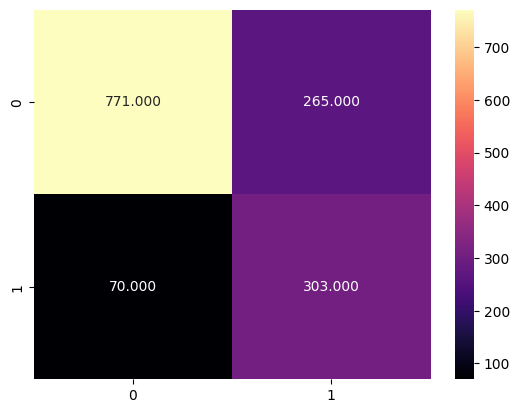

In [ ]:
# The heatmap (Confusion matrix) showing the TP,TN,FP,FN
sns.heatmap(
                data  = confusion_matrix(y_test,y_pred_xgbc),
                cmap = 'magma',
                annot = True,
                fmt = '.3f'
)
plt.show()

In [ ]:
confusion_matrix(y_test,y_pred_xgbc) # Confusion matrix : simple

array([[771, 265],
       [ 70, 303]])

## Analyzing and Visualizing Important Features

In [ ]:
# Extracts important features from the model which had highest importance according to gini .
important_features = pd.DataFrame(
                                    {
                                            'Features' : X_train.columns , 
                                            'Importance' : xgbc.feature_importances_
                                    }
).sort_values(by='Importance',ascending=False)

In [ ]:
important_features # Here we can see that contract has the highest importance for Churn.

,Features,Importance
14,Contract,0.563470
7,InternetService,0.052686
5,PhoneService,0.035654
13,StreamingMovies,0.034212
4,tenure,0.033112
20,Payment_by__Electronic check,0.029354
16,MonthlyCharges,0.025007
8,OnlineSecurity,0.018664
6,MultipleLines,0.018661
9,OnlineBackup,0.018630


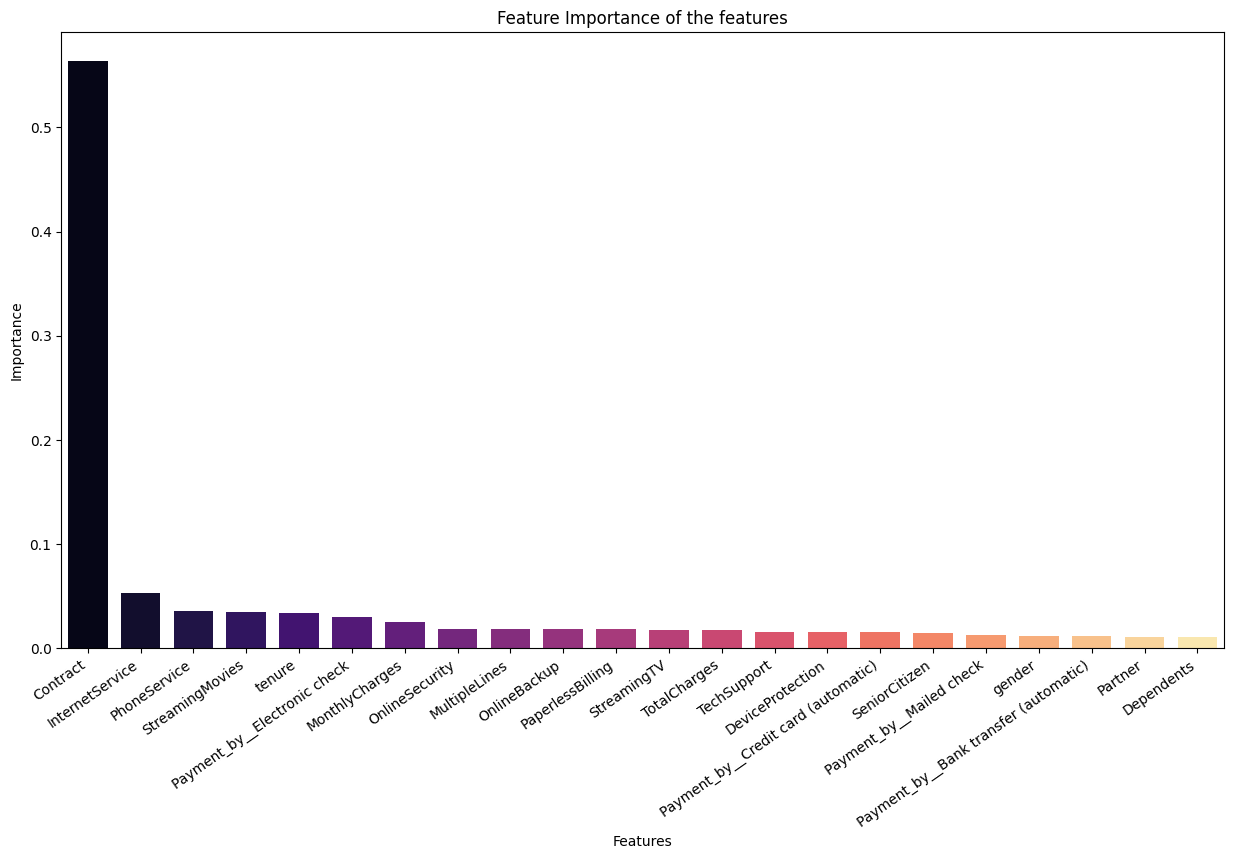

In [ ]:
# Plotting the Feature Importance of the features 
plt.figure(figsize=(15,8))
sns.barplot(
                data = important_features , 
                x = 'Features' ,
                y = 'Importance' , 
                hue = 'Features',
                palette = 'magma',
                width = 1 ,
                gap = 0.25,
                saturation = 0.9
)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance of the features')
plt.xticks(rotation=35, ha='right')
 
plt.show()

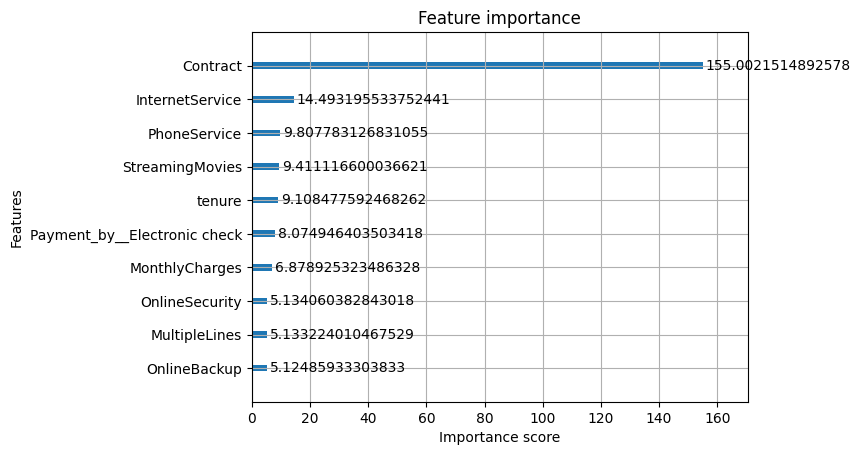

In [ ]:
# Similary we can use the plot_importance graph with additional settings.
plot_importance(    
                    xgbc, 
                    importance_type='gain', 
                    max_num_features=10 
                )
plt.show()


In [ ]:
# Gives us a high definition image of the passed tree index of the model.
import xgboost as xgb
from xgboost import plot_tree
import matplotlib.pyplot as plt

# 1. Use the 'graphviz' engine to export
# num_trees=0 is the first tree
graph = xgb.to_graphviz(xgbc, tree_idx=0)

# 2. Render and save to a file
graph.render("churn_tree_0", format="png", cleanup=True) 
# Open the 'churn_tree_0.png' file in your folder to see it clearly!


'churn_tree_0.png'

In [ ]:
# Gives us a Amazing Interactive image of the passed tree index of the model and the feature names.
import dtreeviz

# Create the viz object
viz_model = dtreeviz.model(xgbc, 
                           X_train=X_train, y_train=y_train,
                           feature_names=X_train.columns.tolist(),
                           target_name='Churn',
                           class_names=['Stay', 'Churn'],
                           tree_index=0) # Look at the first tree

viz_model.view()

